In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score

### Load datasets

In [3]:
customers_df = pd.read_csv("Customers.csv")
products_df = pd.read_csv("Products.csv")
transactions_df = pd.read_csv("Transactions.csv")

### Data Processing 

In [5]:
# Aggregate transaction data to customer level
customer_transactions = transactions_df.groupby('CustomerID').agg({
    'TotalValue': ['sum', 'mean', 'count'],
    'Quantity': 'sum'
}).reset_index()
customer_transactions.columns = ['CustomerID', 'TotalSpent', 'AverageTransactionValue', 'TransactionCount', 'TotalQuantity']

In [7]:
# Merge with customer profile data
customer_data = pd.merge(customers_df, customer_transactions, on='CustomerID', how='left')

In [8]:
# Handle missing values
customer_data.fillna(0, inplace=True)

In [9]:
# Encode categorical variables
customer_data['Region'] = customer_data['Region'].astype('category').cat.codes

In [10]:
# Feature selection
features = ['Region', 'TotalSpent', 'AverageTransactionValue', 'TransactionCount', 'TotalQuantity']
X = customer_data[features]

In [11]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# Clustering and Evaluation
# Trying different numbers of clusters
db_indices = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    db_index = davies_bouldin_score(X_scaled, labels)
    silhouette_avg = silhouette_score(X_scaled, labels)

    db_indices.append(db_index)
    silhouette_scores.append(silhouette_avg)

F:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
F:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
F:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
F:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

In [13]:
# Plotting DB Index and Silhouette Score
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

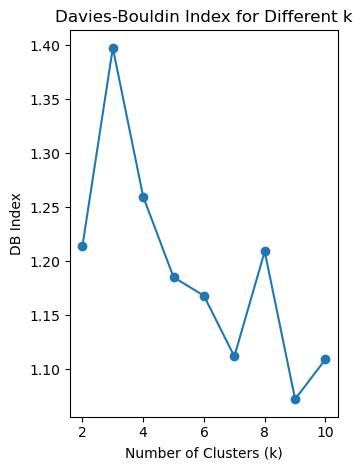

In [14]:
plt.subplot(1, 2, 1)
plt.plot(k_values, db_indices, marker='o')
plt.title('Davies-Bouldin Index for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('DB Index')
plt.tight_layout()
plt.show()

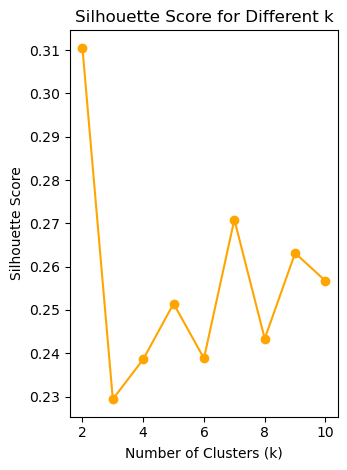

In [15]:
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

In [17]:
import numpy as np

In [18]:
# Final Clustering with optimal k
optimal_k = k_values[np.argmin(db_indices)]  # Using DB Index to determine optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
customer_data['Cluster'] = kmeans_final.fit_predict(X_scaled)

F:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


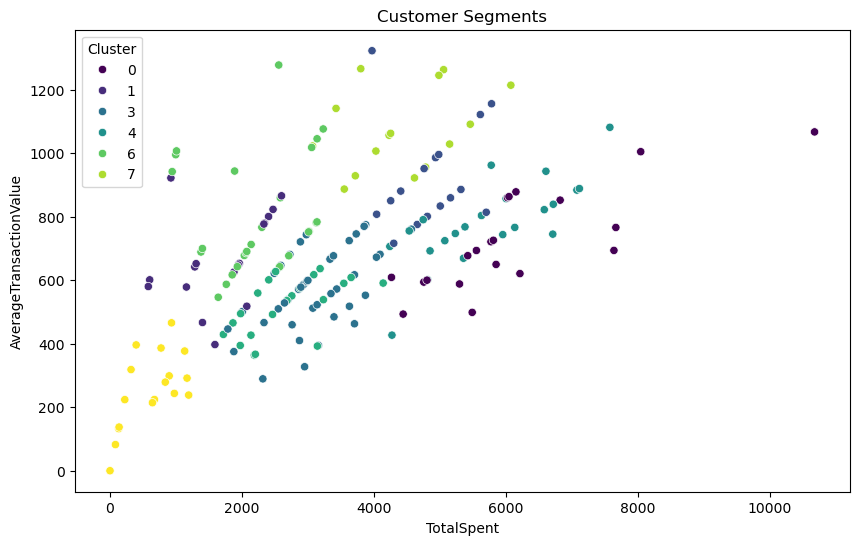

In [19]:
# Visualizing Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='TotalSpent', y='AverageTransactionValue', hue='Cluster', data=customer_data, palette='viridis')
plt.title('Customer Segments')
plt.show()